In [1]:
# Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

<Axes: ylabel='count'>

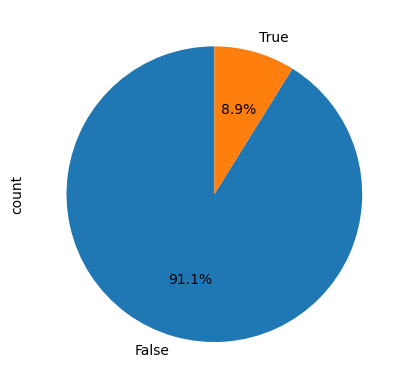

In [6]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle= 90, autopct='%1.1f%%')

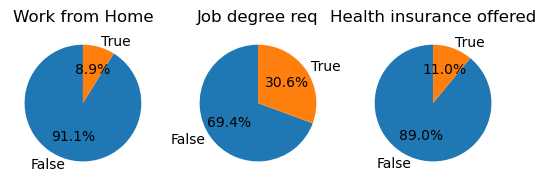

In [7]:
fig, ax = plt.subplots(1,3)
dict_column = {
    'job_work_from_home' : 'Work from Home',
    'job_no_degree_mention' : 'Job degree req',
    'job_health_insurance' : 'Health insurance offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle= 90, autopct='%1.1f%%', labels = ['False', 'True'])
    ax[i].set_title(title)